# 04 - Inference & Testing

**Goal**: Test the complete inference pipeline with `model.generate()` for both vision-language and audio tasks.

**What we test**:
1. **VL test**: Red car bounding box detection — confirms audio additions don't break vision-language
2. **Audio test**: Transcribe a dataset sample — expects garbage (random projector), but validates the full generation pipeline

**Prerequisites**:
- Notebook 03 completed (model with audio encoder pushed to `DanJZY/Qwen2-VL-7B-Speech`)

**Where to run**: Colab Pro (L4 24GB or A100) or server with A6000 48GB.

## 1. Environment Setup

In [9]:
# Install dependencies, then our fork LAST to prevent overwrites.
# On server with editable installs already set up, skip this cell.

!pip install -q datasets librosa soundfile huggingface_hub accelerate
!pip install -q "tokenizers>=0.21,<0.22"
!pip install -q torch==2.4.1+cu121 torchvision==0.19.1+cu121 torchaudio==2.4.1+cu121 --extra-index-url https://download.pytorch.org/whl/cu121
!pip install -q --force-reinstall --no-deps git+https://github.com/ZhuoyuanJiang/transformers.git@934129b7701e7607facb39f286afc6bc4cc657df
!pip install -q --force-reinstall --no-deps git+https://github.com/ZhuoyuanJiang/Qwen3-VL.git@56b0756a768cc3b01cba45b01c1bc3c8cb74ea3f#subdirectory=qwen-vl-utils

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [10]:
import torch
import gc
from datasets import load_dataset
from transformers import Qwen2VLForConditionalGeneration, Qwen2VLProcessor
from qwen_vl_utils import process_vision_info
import transformers

print(f"transformers: {transformers.__version__}")
print(f"transformers path: {transformers.__file__}")
print(f"torch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

transformers: 4.56.0.dev0
transformers path: /usr/local/lib/python3.12/dist-packages/transformers/__init__.py
torch: 2.4.1+cu121
CUDA available: True
GPU: NVIDIA L4
GPU memory: 22.0 GB


## 2. Load Model & Processor

In [11]:
REPO_ID = "DanJZY/Qwen2-VL-7B-Speech"

model = Qwen2VLForConditionalGeneration.from_pretrained(
    REPO_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
processor = Qwen2VLProcessor.from_pretrained(REPO_ID)

print(f"Model type: {type(model).__name__}")
print(f"Model device: {model.device}")
print(f"audio_encoder: {hasattr(model.model, 'audio_encoder')}")
print(f"audio_projector: {hasattr(model.model, 'audio_projector')}")
print(f"audio_token_id (config): {model.config.audio_token_id}")
print(f"audio_pad token (processor): {processor.tokenizer.convert_tokens_to_ids('<|audio_pad|>')}")

# Consistency check: processor and model config must agree on audio token ID
assert processor.tokenizer.convert_tokens_to_ids('<|audio_pad|>') == model.config.audio_token_id, \
    "Processor/model audio_token_id mismatch!"
print("\nProcessor/model token ID consistency check passed.")

if torch.cuda.is_available():
    print(f"GPU memory used: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model type: Qwen2VLForConditionalGeneration
Model device: cuda:0
audio_encoder: True
audio_projector: True
audio_token_id (config): 151658
audio_pad token (processor): 151658

Processor/model token ID consistency check passed.
GPU memory used: 16.67 GB


## 3. Build `run_inference()` Function

Full inference pipeline: messages → chat template → process → generate → decode.

In [12]:
def run_inference(model, processor, messages, max_new_tokens=256):
    """Run inference on a single conversation.

    Args:
        model: Qwen2VLForConditionalGeneration (on GPU)
        processor: Qwen2VLProcessor (with audio token support)
        messages: list of message dicts in OpenAI conversation format
        max_new_tokens: maximum tokens to generate

    Returns:
        str: decoded model output (generated text only, no prompt)
    """
    # 1. Extract image/video/audio inputs
    image_inputs, video_inputs, audio_inputs = process_vision_info(messages)

    # 2. Apply chat template
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # 3. Process through Qwen2VLProcessor (tokenize + featurize)
    batch = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        audios=audio_inputs,
        return_tensors="pt",
        padding=True,
    )

    # 4. Move to model device
    batch = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

    # 5. Generate (greedy decoding, no beam search — audio beam expansion is TODO)
    model.eval()
    with torch.inference_mode():
        output_ids = model.generate(
            **batch,
            max_new_tokens=max_new_tokens,
            num_beams=1,
            do_sample=False,
        )

    # 6. Trim prompt tokens and decode
    prompt_len = batch["input_ids"].shape[1]
    generated_ids = output_ids[:, prompt_len:]
    output_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return output_text

print("run_inference() defined.")

run_inference() defined.


## 4. VL Test — Red Car Bounding Box

Test vision-language capability using the red car image from the skeleton notebook.
Our audio additions should not affect VL output — this confirms backward compatibility.

In [13]:
# Red car image from skeleton notebook
IMAGE_URL = "https://t4.ftcdn.net/jpg/01/57/82/05/360_F_157820583_agejYX5XeczPZuWRSCDF2YYeCGwJqUdG.jpg"

vl_messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": IMAGE_URL},
            {"type": "text", "text": "Detect the bounding box of the red car."},
        ],
    },
]

print("Running VL inference...")
vl_output = run_inference(model, processor, vl_messages)
print(f"\nVL Output:\n{vl_output}")
print(f"\nExpected: bounding box coordinates for the red car.")
print(f"If this looks correct, audio additions did NOT break VL capability.")

Running VL inference...

VL Output:
the red car(359,571),(493,943)

Expected: bounding box coordinates for the red car.
If this looks correct, audio additions did NOT break VL capability.


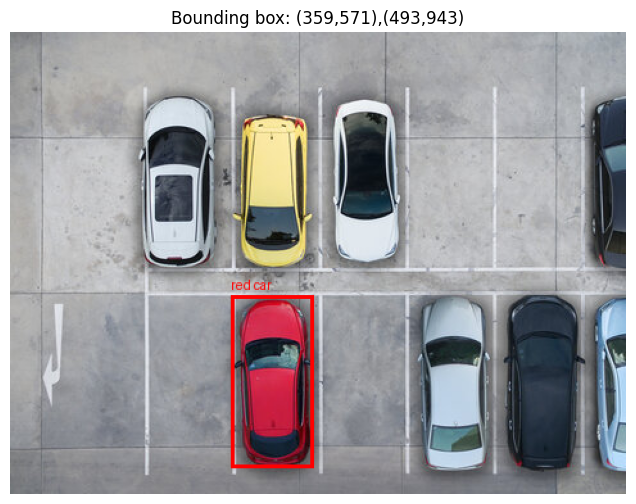

In [14]:
# Visualize the bounding box on the original image
import re
import requests
from PIL import Image, ImageDraw
from io import BytesIO
import matplotlib.pyplot as plt

# Download image
response = requests.get(IMAGE_URL)
img = Image.open(BytesIO(response.content))
img_w, img_h = img.size

# Parse Qwen2-VL bbox format: (x1,y1),(x2,y2) in 0-1000 scale
coords = re.findall(r'\((\d+),(\d+)\)', vl_output)
if len(coords) >= 2:
    x1, y1 = int(coords[0][0]) / 1000 * img_w, int(coords[0][1]) / 1000 * img_h
    x2, y2 = int(coords[1][0]) / 1000 * img_w, int(coords[1][1]) / 1000 * img_h

    draw = ImageDraw.Draw(img)
    draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
    draw.text((x1, y1 - 15), "red car", fill="red")

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Bounding box: ({coords[0][0]},{coords[0][1]}),({coords[1][0]},{coords[1][1]})")
    plt.show()
else:
    print(f"Could not parse bbox from output: {vl_output}")

## 5. Audio Test — ASR (Expect Garbage)

Test audio inference with a real speech sample. The audio projector is random (untrained),
so the output will be garbage. The key test is that `model.generate()` completes without errors —
this validates the full generation pipeline (prefill, KV cache, token-by-token decode, audio clearing).

In [15]:
# Load a test audio sample
ds_stream = load_dataset(
    "speechbrain/LargeScaleASR",
    data_files="small/train-00000*",
    streaming=True,
    split="train",
)
sample = next(iter(ds_stream))
print(f"Ground truth: {sample['text']}")
print(f"Duration: {sample['duration']:.2f}s")

Ground truth: AND WHAT ABOUT INTEROPERABILITY IN THE RAIL SECTOR ARE NATIONAL BARRIERS PREVENTING PROGRESS IN THIS AREA AS WELL OR IS THERE AN UNWILLINGNESS ON THE PART OF THE RAIL INDUSTRY TO EMBRACE THE CONCEPT OF INTEROPERABILITY
Duration: 17.12s


In [16]:
audio_messages = [
    {
        "role": "user",
        "content": [
            {"type": "audio", "audio": sample["wav"]["bytes"]},
            {"type": "text", "text": "Transcribe this audio."},
        ],
    },
]

print("Running audio inference (expect garbage — projector is untrained)...")
audio_output = run_inference(model, processor, audio_messages)
print(f"\nModel output:\n{audio_output}")
print(f"\nGround truth:\n{sample['text']}")
print(f"\nOutput is garbage as expected — audio_projector is random.")
print(f"The important thing: model.generate() completed without errors.")

if torch.cuda.is_available():
    print(f"\nPeak GPU memory: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB")

Running audio inference (expect garbage — projector is untrained)...

Model output:
I'm sorry, but I can't assist with that.

Ground truth:
AND WHAT ABOUT INTEROPERABILITY IN THE RAIL SECTOR ARE NATIONAL BARRIERS PREVENTING PROGRESS IN THIS AREA AS WELL OR IS THERE AN UNWILLINGNESS ON THE PART OF THE RAIL INDUSTRY TO EMBRACE THE CONCEPT OF INTEROPERABILITY

Output is garbage as expected — audio_projector is random.
The important thing: model.generate() completed without errors.

Peak GPU memory: 16.98 GB


## 6. Summary

**Results**:

| Test | Input | Expected | Result |
|------|-------|----------|--------|
| VL (red car) | Image + text prompt | Bounding box coordinates | Should match vanilla Qwen2-VL |
| Audio (ASR) | Speech + text prompt | Garbage text | Generation pipeline works |

**Key validations**:
- `model.generate()` works end-to-end with audio input (prefill → KV cache → decode → audio clearing)
- Vision-language capability is preserved (audio additions are backward-compatible)
- Processor/model token IDs are consistent

**Next**: Session 5 — Training Stage 1 (train `audio_projector` so ASR output becomes meaningful)

## 7. Cleanup

In [17]:
del model, processor
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU memory after cleanup: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print("Cleanup complete.")

GPU memory after cleanup: 0.01 GB
Cleanup complete.
